# 🏢 AI Leadership Insight & Decision Agent
## GenAI Coding Challenge — Multi-Method RAG Comparison with LangGraph

**Objective:** Build an AI agent that ingests company documents and answers leadership questions about performance, strategy, and risks — using multiple retrieval methods, then benchmarking them side-by-side with proper metrics and visualizations.

### Architecture Overview
```
User Question → Semantic Cache → Query Planner (LLM) → Hybrid Retrieval → Agent Router → Structured Response + Charts
                    ↓ (hit)                                                      ↓
               Instant Answer                                          LangFlow-exportable Pipeline
```

### Methods Compared
| # | Method | Retrieval | Reranking |
|---|--------|-----------|-----------|
| 1 | **Naive RAG** | Dense (FAISS + Ada-002) | None |
| 2 | **BM25 RAG** | Sparse (BM25) | None |
| 3 | **Hybrid RAG** | Dense + Sparse (RRF) | None |
| 4 | **Hybrid + Reranker** | Dense + Sparse (RRF) | LLM-based reranker |
| 5 | **Agentic RAG (LangGraph)** | Hybrid + Reranker | + Query Decomposition + Tool Use |

### Production Features
- **Semantic Query Cache** — Embedding-similarity cache avoids redundant LLM calls (cosine sim ≥ 0.92 → instant response)
- **LangFlow Export** — Pipeline exported as JSON for visual editing and one-click API deployment

---

In [ ]:
# ============================================================
# CELL 1: Configuration & Azure OpenAI Setup
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────
#   Azure OpenAI Credentials  (Update these as needed)
# ──────────────────────────────────────────────────────────────
AZURE_OPENAI_API_KEY       = ""
AZURE_OPENAI_ENDPOINT      = "https://ue2daoipocaoa0l.openai.azure.com/"
AZURE_OPENAI_API_VERSION   = "2024-02-15-preview"
AZURE_CHAT_MODEL           = "gpt-5"
AZURE_EMBEDDING_MODEL      = "text-embedding"

os.environ["AZURE_OPENAI_API_KEY"]     = AZURE_OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"]    = AZURE_OPENAI_ENDPOINT
os.environ["AZURE_OPENAI_API_VERSION"] = AZURE_OPENAI_API_VERSION

print(f"Azure OpenAI configured — Endpoint: {AZURE_OPENAI_ENDPOINT}")

Azure OpenAI configured — Endpoint: https://ue2daoipocaoa0l.openai.azure.com/


In [7]:
# ============================================================
# CELL 2: Import All Libraries
# ============================================================
import json
import time
import textwrap
import hashlib
from typing import TypedDict, List, Dict, Any, Optional, Annotated
from collections import defaultdict

# LangChain & LangGraph
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages

# Retrieval
from rank_bm25 import BM25Okapi

# PDF & Word document support
import pymupdf4llm
from docx import Document as DocxDocument

# Data & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
# ============================================================
# CELL 3: Initialize LLM & Embedding Models
# ============================================================
llm = AzureChatOpenAI(
    azure_deployment=AZURE_CHAT_MODEL,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_OPENAI_API_VERSION,
    max_tokens=2048,
)

embeddings = AzureOpenAIEmbeddings(
    model=AZURE_EMBEDDING_MODEL,
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_OPENAI_API_VERSION,
)

# Quick connectivity test
test_resp = llm.invoke([HumanMessage(content="Reply with OK")])
test_embed = embeddings.embed_query("test")
print(f"LLM test: {test_resp.content} | Embedding dim: {len(test_embed)}")

LLM test: OK | Embedding dim: 1536


## Step 2: Document Ingestion & Chunking Pipeline
**Core Capability 1 — Ingest and process company documents.**

Load all documents (`.txt`, `.pdf`, `.docx`), apply recursive character splitting (350-char chunks, 100-char overlap), and prepare chunks for indexing.

In [9]:
# ============================================================
# CELL 5: Document Ingestion & Chunking (TXT + PDF + DOCX)
# ============================================================
# The agent ingests and processes company documents from the
# sample_company_docs/ folder. Supports .txt, .pdf, and .docx.

DOC_DIR = os.path.join(os.getcwd(), "sample_company_docs")
os.makedirs(DOC_DIR, exist_ok=True)

def load_documents(doc_dir: str) -> List[Document]:
    """
    Step 1 of 3: INGEST AND PROCESS COMPANY DOCUMENTS.
    Load all documents (txt, pdf, docx) from the specified directory.
    Each file is read, text extracted, and wrapped as a LangChain Document.
    """
    documents = []
    for fname in sorted(os.listdir(doc_dir)):
        fpath = os.path.join(doc_dir, fname)
        if not os.path.isfile(fpath):
            continue
        ext = os.path.splitext(fname)[1].lower()

        if ext == ".pdf":
            content = pymupdf4llm.to_markdown(fpath)
        elif ext == ".docx":
            doc = DocxDocument(fpath)
            content = "\n\n".join(p.text for p in doc.paragraphs if p.text.strip())
        elif ext == ".txt":
            with open(fpath, "r", encoding="utf-8") as f:
                content = f.read()
        else:
            continue

        if content.strip():
            documents.append(Document(
                page_content=content,
                metadata={"source": fname, "file_path": fpath, "file_type": ext}
            ))
    return documents

def chunk_documents(documents: List[Document], chunk_size: int = 350, chunk_overlap: int = 100) -> List[Document]:
    """
    Split documents into smaller chunks for retrieval indexing.
    Smaller chunks (350 chars) reduce latency for reranking methods.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
        length_function=len,
    )
    chunks = []
    for doc in documents:
        doc_chunks = splitter.split_documents([doc])
        for i, chunk in enumerate(doc_chunks):
            chunk.metadata["chunk_id"] = i
            chunk.metadata["total_chunks"] = len(doc_chunks)
        chunks.extend(doc_chunks)
    return chunks

# Execute ingestion pipeline
raw_documents = load_documents(DOC_DIR)
all_chunks = chunk_documents(raw_documents)

print(f"Documents loaded: {len(raw_documents)}")
print(f"Total chunks created: {len(all_chunks)} (chunk_size=350, overlap=100)")
if all_chunks:
    from collections import Counter
    source_counts = Counter(c.metadata['source'] for c in all_chunks)
    for src, cnt in source_counts.items():
        print(f"   {src}: {cnt} chunks")
else:
    print(f"No documents found in {DOC_DIR}")

Documents loaded: 4
Total chunks created: 18 (chunk_size=350, overlap=100)
   Annual_Report_FY2025.txt: 6 chunks
   Q3_FY2025_Quarterly_Report.txt: 4 chunks
   Risk_Assessment_H2_FY2025.txt: 4 chunks
   Strategy_Update_Q4_FY2025.txt: 4 chunks


## Step 3: Retrieve Relevant Information (5 Methods)
**Core Capability 2 — Retrieve relevant information for a given question.**

We build multiple retrieval backends for fair comparison:

1. **Naive Dense RAG** — FAISS vector similarity only
2. **BM25 Sparse RAG** — Keyword-based TF-IDF ranking  
3. **Hybrid RAG (RRF)** — Reciprocal Rank Fusion of Dense + Sparse
4. **Hybrid + LLM Reranker** — RRF + LLM-based relevance scoring
5. **Agentic RAG (LangGraph)** — Full agent with query decomposition, hybrid retrieval, reranking, and structured output

In [10]:
# ============================================================
# CELL 6: Build Vector Store (Dense Retrieval) & BM25 Index (Sparse)
# ============================================================

if not all_chunks:
    raise RuntimeError(f"No document chunks found. Place .txt/.pdf/.docx files in: {DOC_DIR}")

# --- Dense: FAISS vector store ---
t0 = time.time()
vector_store = FAISS.from_documents(all_chunks, embeddings)
faiss_build_time = time.time() - t0

# --- Sparse: BM25 index ---
t0 = time.time()
tokenized_chunks = [c.page_content.lower().split() for c in all_chunks]
bm25_index = BM25Okapi(tokenized_chunks)
bm25_build_time = time.time() - t0

print(f"FAISS index built in {faiss_build_time:.2f}s | BM25 index built in {bm25_build_time:.2f}s | {len(all_chunks)} vectors")

FAISS index built in 1.30s | BM25 index built in 0.00s | 18 vectors


## Upload PDF / Word Documents at Runtime
Drop a `.pdf` or `.docx` file into the `sample_company_docs/` folder and call `upload_document(filepath)` to ingest it into the knowledge base.  
The function extracts text using **pymupdf4llm** (PDF) or **python-docx** (Word), chunks the content, and rebuilds both FAISS and BM25 indexes automatically.

In [11]:
# ============================================================
# CELL 6b: Upload & Ingest PDF / Word Documents
# ============================================================

def upload_document(filepath: str) -> dict:
    """
    Ingest a PDF or DOCX file into the knowledge base.
    Extracts text, chunks it, adds to global chunks, and rebuilds
    FAISS + BM25 indexes.

    Args:
        filepath: Path to the .pdf or .docx file.

    Returns:
        dict with status, filename, chunks_added, total_chunks.

    Usage:
        upload_document("path/to/report.pdf")
        upload_document("path/to/memo.docx")
    """
    global vector_store, bm25_index, all_chunks, tokenized_chunks

    import shutil

    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    fname = os.path.basename(filepath)
    ext = os.path.splitext(fname)[1].lower()

    if ext not in (".pdf", ".docx"):
        raise ValueError(f"Unsupported file type '{ext}'. Only .pdf and .docx are supported.")

    # Copy file into sample_company_docs/ if not already there
    dest = os.path.join(DOC_DIR, fname)
    if os.path.abspath(filepath) != os.path.abspath(dest):
        shutil.copy2(filepath, dest)

    # Extract text
    if ext == ".pdf":
        text = pymupdf4llm.to_markdown(dest)
    else:
        doc = DocxDocument(dest)
        text = "\n\n".join(p.text for p in doc.paragraphs if p.text.strip())

    if not text.strip():
        os.remove(dest)
        raise ValueError(f"No text could be extracted from '{fname}'.")

    # Chunk (matching main pipeline: 350 chars, 100 overlap)
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=350, chunk_overlap=100,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    new_doc = Document(page_content=text, metadata={"source": fname, "file_type": ext})
    new_chunks = splitter.split_documents([new_doc])
    for i, chunk in enumerate(new_chunks):
        chunk.metadata["chunk_id"] = i

    all_chunks.extend(new_chunks)

    # Rebuild FAISS index
    vector_store = FAISS.from_documents(all_chunks, embeddings)

    # Rebuild BM25 index
    tokenized_chunks = [c.page_content.lower().split() for c in all_chunks]
    bm25_index = BM25Okapi(tokenized_chunks)

    # Clear query cache if it exists
    if 'query_cache' in globals():
        try:
            query_cache.cache.clear()
            query_cache.stats = {"hits": 0, "misses": 0}
        except Exception:
            pass

    result = {
        "status": "success",
        "filename": fname,
        "chunks_added": len(new_chunks),
        "total_chunks": len(all_chunks),
    }
    print(f"'{fname}' ingested — {len(new_chunks)} new chunks. Total: {len(all_chunks)} chunks.")
    return result

print("upload_document() ready.")

upload_document() ready.


In [12]:
# ============================================================
# CELL 7: Define Retrieval Functions for All Methods
# ============================================================

def retrieve_dense(query: str, k: int = 5) -> List[Document]:
    """Method 1: Pure dense retrieval via FAISS."""
    return vector_store.similarity_search(query, k=k)

def retrieve_bm25(query: str, k: int = 5) -> List[Document]:
    """Method 2: Pure sparse retrieval via BM25."""
    tokenized_query = query.lower().split()
    scores = bm25_index.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:k]
    return [all_chunks[i] for i in top_indices]

def reciprocal_rank_fusion(dense_docs: List[Document], sparse_docs: List[Document], k: int = 60) -> List[Document]:
    """Combine dense + sparse results using Reciprocal Rank Fusion."""
    doc_scores = defaultdict(float)
    doc_map = {}
    for rank, doc in enumerate(dense_docs):
        key = hashlib.md5(doc.page_content[:200].encode()).hexdigest()
        doc_scores[key] += 1.0 / (rank + k)
        doc_map[key] = doc
    for rank, doc in enumerate(sparse_docs):
        key = hashlib.md5(doc.page_content[:200].encode()).hexdigest()
        doc_scores[key] += 1.0 / (rank + k)
        doc_map[key] = doc
    sorted_keys = sorted(doc_scores.keys(), key=lambda x: doc_scores[x], reverse=True)
    return [doc_map[k] for k in sorted_keys]

def retrieve_hybrid(query: str, k: int = 5) -> List[Document]:
    """Method 3: Hybrid retrieval (Dense + BM25 + RRF)."""
    dense_results = retrieve_dense(query, k=k*2)
    sparse_results = retrieve_bm25(query, k=k*2)
    fused = reciprocal_rank_fusion(dense_results, sparse_results)
    return fused[:k]

def llm_rerank(query: str, documents: List[Document], top_n: int = 5) -> List[Document]:
    """Rerank documents using LLM-based relevance scoring."""
    if not documents:
        return []
    
    rerank_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a relevance judge. Given a query and a document chunk, rate relevance 0-10. Reply with ONLY a number."),
        ("human", "Query: {query}\n\nDocument:\n{document}\n\nRelevance score (0-10):")
    ])
    
    scored_docs = []
    for doc in documents[:min(len(documents), 10)]:
        try:
            resp = llm.invoke(rerank_prompt.format_messages(
                query=query, 
                document=doc.page_content[:500]
            ))
            score = float(resp.content.strip())
        except:
            score = 5.0
        scored_docs.append((score, doc))
    
    scored_docs.sort(key=lambda x: x[0], reverse=True)
    return [doc for _, doc in scored_docs[:top_n]]

def retrieve_hybrid_reranked(query: str, k: int = 5) -> List[Document]:
    """Method 4: Hybrid retrieval + LLM reranker."""
    hybrid_results = retrieve_hybrid(query, k=k*2)
    return llm_rerank(query, hybrid_results, top_n=k)

print("All retrieval functions defined.")

All retrieval functions defined.


### Semantic Query Cache (Production-Ready Feature)
A lightweight in-memory cache that uses **embedding cosine similarity** to detect semantically equivalent queries.  
If a new query is ≥ 92% similar to a previously answered one, the cached answer is returned instantly — **zero LLM cost, sub-millisecond latency**.

This is a simplified version of what production systems use (e.g., [GPTCache](https://github.com/zilliztech/GPTCache), Redis Semantic Cache).

In [13]:
# ============================================================
# CELL 7b: Semantic Query Cache — Embedding-Based Similarity Cache
# ============================================================

class SemanticQueryCache:
    """
    Production-ready semantic cache for RAG pipelines.
    
    Uses cosine similarity between query embeddings to detect
    semantically equivalent questions and return cached answers
    instantly — saving LLM cost and reducing latency to <1ms.
    
    Features:
    - Configurable similarity threshold (default: 0.92)
    - LRU-style eviction when max capacity reached
    - Per-method caching (each RAG method has its own cache space)
    - Cache statistics tracking (hits, misses, hit rate)
    """
    
    def __init__(self, embedding_fn, similarity_threshold: float = 0.92, max_size: int = 50):
        self.embedding_fn = embedding_fn
        self.threshold = similarity_threshold
        self.max_size = max_size
        self.cache = []
        self.stats = {"hits": 0, "misses": 0}
    
    def _cosine_similarity(self, a: List[float], b: List[float]) -> float:
        """Compute cosine similarity between two vectors."""
        a_arr, b_arr = np.array(a), np.array(b)
        return float(np.dot(a_arr, b_arr) / (np.linalg.norm(a_arr) * np.linalg.norm(b_arr) + 1e-10))
    
    def get(self, query: str, method: str = "default") -> Optional[Dict]:
        """Look up a semantically similar query in the cache."""
        query_embedding = self.embedding_fn(query)
        
        best_score = 0.0
        best_result = None
        
        for cached_emb, cached_query, cached_method, cached_result in self.cache:
            if cached_method != method:
                continue
            sim = self._cosine_similarity(query_embedding, cached_emb)
            if sim > best_score:
                best_score = sim
                best_result = (cached_query, cached_result)
        
        if best_score >= self.threshold and best_result is not None:
            self.stats["hits"] += 1
            return {
                "result": best_result[1],
                "matched_query": best_result[0],
                "similarity": best_score,
                "cache_hit": True,
            }
        
        self.stats["misses"] += 1
        return None
    
    def put(self, query: str, method: str, result: Dict):
        """Store a query-result pair in the cache."""
        query_embedding = self.embedding_fn(query)
        if len(self.cache) >= self.max_size:
            self.cache.pop(0)
        self.cache.append((query_embedding, query, method, result))
    
    @property
    def hit_rate(self) -> float:
        total = self.stats["hits"] + self.stats["misses"]
        return self.stats["hits"] / total if total > 0 else 0.0
    
    def summary(self) -> str:
        total = self.stats["hits"] + self.stats["misses"]
        return (
            f"Cache Stats: {self.stats['hits']} hits / {self.stats['misses']} misses "
            f"({self.hit_rate:.1%} hit rate) | {len(self.cache)} entries cached"
        )


# Initialize the semantic cache
query_cache = SemanticQueryCache(
    embedding_fn=embeddings.embed_query,
    similarity_threshold=0.92,
    max_size=50,
)

print(f"Semantic Query Cache initialized (threshold={query_cache.threshold}, max_size={query_cache.max_size})")

Semantic Query Cache initialized (threshold=0.92, max_size=50)


## Step 4: LangGraph Agentic RAG Pipeline (Method 5)
The most advanced method — a full LangGraph state machine with:
- **Query Analysis** — classifies question type and complexity
- **Query Decomposition** — breaks complex questions into sub-queries
- **Hybrid Retrieval + Reranking** — best retrieval pipeline
- **Answer Synthesis** — generates grounded, structured responses with source citations
- **Quality Gate** — self-checks for hallucination and completeness

In [14]:
# ============================================================
# CELL 8: LangGraph Agentic RAG — State & Node Definitions
# ============================================================
# OPTIMIZED: Merged analyze+decompose (1 LLM call instead of 2)
#            Batch reranking (1 LLM call instead of ~10)
#            Total LLM calls per query: ~4 (down from ~14)
# ============================================================

class AgentState(TypedDict):
    """State for the LangGraph RAG agent."""
    question: str
    question_type: str
    sub_queries: List[str]
    retrieved_docs: List[Document]
    reranked_docs: List[Document]
    answer: str
    sources: List[str]
    confidence: float
    quality_pass: bool
    iteration: int


# ─── Node 1: Query Analyzer + Decomposer (MERGED — 1 LLM call) ───
def analyze_and_decompose(state: AgentState) -> dict:
    """Classify the query type AND decompose into sub-queries in a single LLM call."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a query analyzer for a corporate leadership AI assistant.
1. Classify the question as FACTUAL, ANALYTICAL, or STRATEGIC.
2. If FACTUAL, return the original question as the only sub-query.
   If ANALYTICAL or STRATEGIC, decompose into 2-3 focused sub-queries
   that can each be answered from corporate documents.

Reply with ONLY a JSON object: {{"type": "FACTUAL", "sub_queries": ["..."]}}"""),
        ("human", "{question}")
    ])
    resp = llm.invoke(prompt.format_messages(question=state["question"]))
    try:
        r = json.loads(resp.content.strip())
        q_type = r.get("type", "ANALYTICAL").upper()
        subs = r.get("sub_queries", [state["question"]])
        if q_type not in ("FACTUAL", "ANALYTICAL", "STRATEGIC"):
            q_type = "ANALYTICAL"
        if not isinstance(subs, list) or not subs:
            subs = [state["question"]]
    except:
        q_type = "ANALYTICAL"
        subs = [state["question"]]
    return {"question_type": q_type, "sub_queries": subs}


# ─── Node 2: Hybrid Retriever ───
def retrieve_documents(state: AgentState) -> dict:
    """Retrieve documents using hybrid (dense + sparse + RRF) for all sub-queries."""
    all_docs = []
    seen = set()
    for sq in state["sub_queries"]:
        docs = retrieve_hybrid(sq, k=5)
        for d in docs:
            key = hashlib.md5(d.page_content[:200].encode()).hexdigest()
            if key not in seen:
                seen.add(key)
                all_docs.append(d)
    return {"retrieved_docs": all_docs}


# ─── Node 3: Batch LLM Reranker (1 LLM call instead of ~10) ───
def batch_rerank_documents(state: AgentState) -> dict:
    """Rerank all retrieved documents in a single LLM call."""
    docs = state["retrieved_docs"]
    if not docs:
        return {"reranked_docs": []}
    if len(docs) <= 5:
        return {"reranked_docs": docs}

    doc_list = "\n\n".join(
        f"[{i}] {d.page_content[:400]}" for i, d in enumerate(docs)
    )
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a relevance judge. Given a query and numbered document chunks, "
                   "return the indices of the 5 most relevant documents ordered by relevance (most relevant first). "
                   "Reply with ONLY a JSON list of integers, e.g. [3, 0, 7, 1, 4]"),
        ("human", "Query: {query}\n\nDocuments:\n{documents}\n\nTop 5 most relevant indices:")
    ])
    resp = llm.invoke(prompt.format_messages(query=state["question"], documents=doc_list))
    try:
        indices = json.loads(resp.content.strip())
        if not isinstance(indices, list):
            indices = list(range(min(5, len(docs))))
        valid = [i for i in indices if isinstance(i, int) and 0 <= i < len(docs)]
        if not valid:
            valid = list(range(min(5, len(docs))))
        return {"reranked_docs": [docs[i] for i in valid[:5]]}
    except:
        return {"reranked_docs": docs[:5]}


# ─── Node 4: Answer Synthesizer ───
def synthesize_answer(state: AgentState) -> dict:
    """Generate a structured, grounded answer from reranked documents."""
    context = "\n\n---\n\n".join([
        f"[Source: {d.metadata.get('source', 'unknown')}]\n{d.page_content}" 
        for d in state["reranked_docs"]
    ])
    
    system_prompt = """You are an AI Leadership Insight Agent for ACME Corporation.
Your role is to provide executive-level answers grounded ONLY in the provided documents.

RULES:
1. Answer ONLY based on the provided context. If information is not available, say so.
2. Cite specific sources using [Source: filename] notation.
3. Use structured formatting with headers and bullet points for readability.
4. For analytical questions, include specific numbers and comparisons.
5. For strategic questions, provide actionable recommendations.
6. Keep the tone professional and concise — suitable for C-suite audience.

RESPONSE FORMAT:
## Key Findings
<main answer with data points>

## Supporting Details  
<additional context and evidence>

## Sources
<list of source documents used>"""

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "Context:\n{context}\n\nQuestion: {question}")
    ])
    
    resp = llm.invoke(prompt.format_messages(context=context, question=state["question"]))
    sources = list(set(d.metadata.get("source", "unknown") for d in state["reranked_docs"]))
    return {"answer": resp.content, "sources": sources}


# ─── Node 5: Quality Gate ───
def quality_check(state: AgentState) -> dict:
    """Self-evaluate answer quality for hallucination and completeness."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a quality checker for AI-generated answers about corporate data.
Evaluate the answer on these criteria:
1. GROUNDED: Is the answer supported by the provided sources? (not hallucinated)
2. COMPLETE: Does it fully address the question?
3. ACCURATE: Are numbers and facts correct based on sources?

Reply with a JSON object: {{"pass": true/false, "confidence": 0.0-1.0, "reason": "brief explanation"}}"""),
        ("human", "Question: {question}\n\nAnswer: {answer}\n\nSources used: {sources}")
    ])
    
    resp = llm.invoke(prompt.format_messages(
        question=state["question"],
        answer=state["answer"],
        sources=", ".join(state["sources"])
    ))
    
    try:
        result = json.loads(resp.content.strip())
        quality_pass = result.get("pass", True)
        confidence = float(result.get("confidence", 0.7))
    except:
        quality_pass = True
        confidence = 0.7
    
    return {"quality_pass": quality_pass, "confidence": confidence, "iteration": state.get("iteration", 0) + 1}


# ─── Conditional Edge: Retry or Finish ───
def should_retry(state: AgentState) -> str:
    """Decide whether to retry answer generation or finish."""
    if not state.get("quality_pass", True) and state.get("iteration", 0) < 2:
        return "retry"
    return "finish"


print("LangGraph agent nodes defined — ~4 LLM calls per query")

LangGraph agent nodes defined — ~4 LLM calls per query


In [15]:
# ============================================================
# CELL 9: Build & Compile the LangGraph (Optimized 5-Node Pipeline)
# ============================================================

workflow = StateGraph(AgentState)

workflow.add_node("analyze_and_decompose", analyze_and_decompose)
workflow.add_node("retrieve_documents", retrieve_documents)
workflow.add_node("batch_rerank", batch_rerank_documents)
workflow.add_node("synthesize_answer", synthesize_answer)
workflow.add_node("quality_check", quality_check)

workflow.add_edge(START, "analyze_and_decompose")
workflow.add_edge("analyze_and_decompose", "retrieve_documents")
workflow.add_edge("retrieve_documents", "batch_rerank")
workflow.add_edge("batch_rerank", "synthesize_answer")
workflow.add_edge("synthesize_answer", "quality_check")

workflow.add_conditional_edges(
    "quality_check",
    should_retry,
    {
        "retry": "synthesize_answer",
        "finish": END
    }
)

agent_graph = workflow.compile()

print(f"LangGraph agent compiled — Nodes: {list(workflow.nodes.keys())}")

LangGraph agent compiled — Nodes: ['analyze_and_decompose', 'retrieve_documents', 'batch_rerank', 'synthesize_answer', 'quality_check']


In [16]:
# ============================================================
# CELL 10: Unified RAG Runner for All 5 Methods
# ============================================================
# ── CORE CAPABILITY 3 ──────────────────────────────────────
# Generate a concise, factual answer GROUNDED in the documents.
# The LLM is instructed to use ONLY the retrieved context and
# cite sources — ensuring every answer is traceable to evidence.
# ============================================================

def generate_answer_simple(query: str, retrieved_docs: List[Document]) -> str:
    """
    Core Capability 3 — Generate a concise, factual answer grounded in the documents.
    Uses retrieved context ONLY. Cites sources. Does NOT hallucinate.
    """
    context = "\n\n---\n\n".join([
        f"[Source: {d.metadata.get('source', 'unknown')}]\n{d.page_content}" 
        for d in retrieved_docs
    ])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an AI Leadership Insight Agent for ACME Corporation.
Answer the question based ONLY on the provided context. Cite sources using [Source: filename].
Be concise, factual, and structured. Use bullet points and headers.
If the information is not in the context, say so clearly."""),
        ("human", "Context:\n{context}\n\nQuestion: {question}")
    ])
    
    resp = llm.invoke(prompt.format_messages(context=context, question=query))
    return resp.content


def run_all_methods(query: str) -> Dict[str, Dict]:
    """Run all 5 RAG methods on a single query and collect results."""
    results = {}
    
    # Method 1: Naive Dense RAG
    t0 = time.time()
    docs_1 = retrieve_dense(query, k=5)
    answer_1 = generate_answer_simple(query, docs_1)
    results["1_Naive_Dense_RAG"] = {
        "answer": answer_1,
        "docs": docs_1,
        "latency": time.time() - t0,
        "sources": list(set(d.metadata["source"] for d in docs_1)),
        "num_docs": len(docs_1)
    }
    
    # Method 2: BM25 Sparse RAG
    t0 = time.time()
    docs_2 = retrieve_bm25(query, k=5)
    answer_2 = generate_answer_simple(query, docs_2)
    results["2_BM25_Sparse_RAG"] = {
        "answer": answer_2,
        "docs": docs_2,
        "latency": time.time() - t0,
        "sources": list(set(d.metadata["source"] for d in docs_2)),
        "num_docs": len(docs_2)
    }
    
    # Method 3: Hybrid RAG (RRF)
    t0 = time.time()
    docs_3 = retrieve_hybrid(query, k=5)
    answer_3 = generate_answer_simple(query, docs_3)
    results["3_Hybrid_RAG_RRF"] = {
        "answer": answer_3,
        "docs": docs_3,
        "latency": time.time() - t0,
        "sources": list(set(d.metadata["source"] for d in docs_3)),
        "num_docs": len(docs_3)
    }
    
    # Method 4: Hybrid + LLM Reranker
    t0 = time.time()
    docs_4 = retrieve_hybrid_reranked(query, k=5)
    answer_4 = generate_answer_simple(query, docs_4)
    results["4_Hybrid_Reranked"] = {
        "answer": answer_4,
        "docs": docs_4,
        "latency": time.time() - t0,
        "sources": list(set(d.metadata["source"] for d in docs_4)),
        "num_docs": len(docs_4)
    }
    
    # Method 5: LangGraph Agentic RAG
    t0 = time.time()
    initial_state = {
        "question": query,
        "question_type": "",
        "sub_queries": [],
        "retrieved_docs": [],
        "reranked_docs": [],
        "answer": "",
        "sources": [],
        "confidence": 0.0,
        "quality_pass": False,
        "iteration": 0,
    }
    agent_result = agent_graph.invoke(initial_state)
    results["5_Agentic_LangGraph"] = {
        "answer": agent_result["answer"],
        "docs": agent_result["reranked_docs"],
        "latency": time.time() - t0,
        "sources": agent_result["sources"],
        "num_docs": len(agent_result["reranked_docs"]),
        "confidence": agent_result.get("confidence", 0.0),
        "question_type": agent_result.get("question_type", ""),
        "sub_queries": agent_result.get("sub_queries", []),
    }
    
    return results

print("Unified RAG runner defined. Ready to benchmark all 5 methods.")

Unified RAG runner defined. Ready to benchmark all 5 methods.


## Step 5: Evaluation Framework — LLM-as-Judge
We evaluate each method on 4 key dimensions using LLM-as-Judge scoring:
- **Faithfulness** (0-10): Is the answer grounded in the source documents?
- **Relevance** (0-10): Does the answer address the question directly?
- **Completeness** (0-10): Does it cover all relevant aspects?
- **Coherence** (0-10): Is it well-structured, clear, and professional?

This approach is widely used when ground-truth labels are unavailable (e.g., RAGAS framework).

In [17]:
# ============================================================
# CELL 11: LLM-as-Judge Evaluation Function
# ============================================================

def evaluate_answer(question: str, answer: str, source_docs: List[Document]) -> Dict[str, float]:
    """Evaluate answer quality using LLM-as-Judge on 4 dimensions."""
    
    context_summary = "\n".join([
        f"- [{d.metadata.get('source','unknown')}]: {d.page_content[:300]}..." 
        for d in source_docs[:5]
    ])
    
    eval_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an expert evaluator assessing the quality of AI-generated answers 
about corporate documents. Evaluate the answer on these 4 dimensions.

Score each dimension from 0 to 10 (integers only).

FAITHFULNESS: Is the answer factually grounded in the provided source documents? 
  10 = every claim is directly supported by sources
  0 = entirely fabricated

RELEVANCE: Does the answer directly address the question asked?
  10 = perfectly addresses the question with appropriate detail
  0 = completely off-topic

COMPLETENESS: Does the answer cover all important aspects of the question?
  10 = comprehensive, nothing important missing
  0 = barely touches the topic

COHERENCE: Is the answer well-organized, clear, and professional?
  10 = excellent structure, clear language, executive-ready
  0 = incoherent or poorly formatted

Reply with ONLY a JSON object:
{{"faithfulness": <int>, "relevance": <int>, "completeness": <int>, "coherence": <int>}}"""),
        ("human", """Question: {question}

Source Documents:
{context}

Answer Being Evaluated:
{answer}

Scores (JSON):""")
    ])
    
    try:
        resp = llm.invoke(eval_prompt.format_messages(
            question=question, context=context_summary, answer=answer
        ))
        scores = json.loads(resp.content.strip())
        for key in ["faithfulness", "relevance", "completeness", "coherence"]:
            if key not in scores or not isinstance(scores[key], (int, float)):
                scores[key] = 5
            scores[key] = max(0, min(10, scores[key]))
    except Exception as e:
        scores = {"faithfulness": 5, "relevance": 5, "completeness": 5, "coherence": 5}
    
    scores["overall"] = round(np.mean([scores["faithfulness"], scores["relevance"], 
                                        scores["completeness"], scores["coherence"]]), 2)
    return scores

print("LLM-as-Judge evaluation function ready.")

LLM-as-Judge evaluation function ready.


## Important: Commenting the code for this step as it will used to evaluate and will took around 6 minutes to run and generate metrics. Basis that we currently choosed a method                                                                            

##### Step 6: Run Full Benchmark — All Methods x All Questions
Execute all 5 methods across the evaluation question set, score each with LLM-as-Judge, and collect timing data.

In [ ]:
# # ============================================================
# # CELL 12: Define Evaluation Questions & Run Full Benchmark
# # ============================================================

# # Evaluation questions covering different types
# EVAL_QUESTIONS = [
#     # Factual questions
#     "What is our current revenue trend?",
#     "What is the company's total revenue and net income for FY2025?",
#     # Analytical questions  
#     "Which departments are underperforming?",
#     "How is the AI-first product transformation progressing?",
#     # Strategic / Risk questions
#     "What were the key risks highlighted in the last quarter?",
#     "What are the top strategic initiatives and their expected revenue impact?",
# ]

# print(f"Running benchmark with {len(EVAL_QUESTIONS)} questions x 5 methods = {len(EVAL_QUESTIONS)*5} evaluations")
# print("=" * 80)

# # Store all results
# all_results = {}
# benchmark_rows = []

# for qi, question in enumerate(EVAL_QUESTIONS):
#     print(f"\n{'='*80}")
#     print(f"Q{qi+1}: {question}")
#     print(f"{'='*80}")
    
#     method_results = run_all_methods(question)
#     all_results[question] = method_results
    
#     for method_name, result in method_results.items():
#         print(f"\n  [{method_name}] Latency: {result['latency']:.2f}s | Sources: {result['sources']}")
        
#         # Evaluate with LLM-as-Judge
#         scores = evaluate_answer(question, result["answer"], result["docs"])
#         result["scores"] = scores
        
#         print(f"  Scores -> Faith: {scores['faithfulness']} | Rel: {scores['relevance']} | "
#               f"Comp: {scores['completeness']} | Coh: {scores['coherence']} | Overall: {scores['overall']}")
        
#         benchmark_rows.append({
#             "question": question,
#             "question_short": question[:50] + "..." if len(question) > 50 else question,
#             "method": method_name,
#             "latency_s": round(result["latency"], 2),
#             "faithfulness": scores["faithfulness"],
#             "relevance": scores["relevance"],
#             "completeness": scores["completeness"],
#             "coherence": scores["coherence"],
#             "overall": scores["overall"],
#             "num_sources": len(result["sources"]),
#         })

# # Create benchmark DataFrame
# df_benchmark = pd.DataFrame(benchmark_rows)
# print(f"\n\nBenchmark complete! {len(df_benchmark)} evaluations collected.")

Running benchmark with 6 questions x 5 methods = 30 evaluations

Q1: What is our current revenue trend?



  [1_Naive_Dense_RAG] Latency: 12.69s | Sources: ['Q3_FY2025_Quarterly_Report.txt', 'Annual_Report_FY2025.txt']
  Scores -> Faith: 10 | Rel: 10 | Comp: 9 | Coh: 10 | Overall: 9.75

  [2_BM25_Sparse_RAG] Latency: 6.01s | Sources: ['Strategy_Update_Q4_FY2025.txt', 'Q3_FY2025_Quarterly_Report.txt', 'Risk_Assessment_H2_FY2025.txt', 'Annual_Report_FY2025.txt']
  Scores -> Faith: 10 | Rel: 10 | Comp: 10 | Coh: 10 | Overall: 10.0

  [3_Hybrid_RAG_RRF] Latency: 11.59s | Sources: ['Strategy_Update_Q4_FY2025.txt', 'Q3_FY2025_Quarterly_Report.txt', 'Annual_Report_FY2025.txt']
  Scores -> Faith: 9 | Rel: 10 | Comp: 9 | Coh: 10 | Overall: 9.5

  [4_Hybrid_Reranked] Latency: 43.12s | Sources: ['Strategy_Update_Q4_FY2025.txt', 'Q3_FY2025_Quarterly_Report.txt', 'Annual_Report_FY2025.txt']
  Scores -> Faith: 9 | Rel: 10 | Comp: 9 | Coh: 10 | Overall: 9.5

  [5_Agentic_LangGraph] Latency: 73.95s | Sources: ['Strategy_Update_Q4_FY2025.txt', 'Q3_FY2025_Quarterly_Report.txt', 'Annual_Report_FY2025.txt']
 

## Step 7: Results Dashboard — Comprehensive Metrics & Visualizations
Detailed analysis of all methods across all evaluation dimensions.

In [19]:
# ============================================================
# CELL 13: Summary Statistics Table
# ============================================================

# Aggregate scores by method
method_summary = df_benchmark.groupby("method").agg({
    "faithfulness": "mean",
    "relevance": "mean",
    "completeness": "mean",
    "coherence": "mean",
    "overall": "mean",
    "latency_s": "mean",
}).round(2)

method_summary = method_summary.sort_values("overall", ascending=False)
method_summary["rank"] = range(1, len(method_summary) + 1)

# Identify the best method
best_method = method_summary.index[0]
print("=" * 90)
print("                    METHOD COMPARISON — AGGREGATE SCORES")
print("=" * 90)
print(method_summary.to_string())
print(f"\n{'='*90}")
print(f"  BEST METHOD: {best_method} (Overall Score: {method_summary.loc[best_method, 'overall']:.2f})")
print(f"{'='*90}")

                    METHOD COMPARISON — AGGREGATE SCORES
                     faithfulness  relevance  completeness  coherence  overall  latency_s  rank
method                                                                                         
4_Hybrid_Reranked            9.50      10.00          9.67      10.00     9.79      38.00     1
1_Naive_Dense_RAG            9.17       9.67          9.17       9.67     9.42      10.29     2
5_Agentic_LangGraph          9.17       9.67          9.33       9.33     9.38      52.57     3
3_Hybrid_RAG_RRF             8.50       9.50          8.83       9.67     9.12      10.74     4
2_BM25_Sparse_RAG            8.83       9.33          8.00       9.17     8.83       6.79     5

  BEST METHOD: 4_Hybrid_Reranked (Overall Score: 9.79)


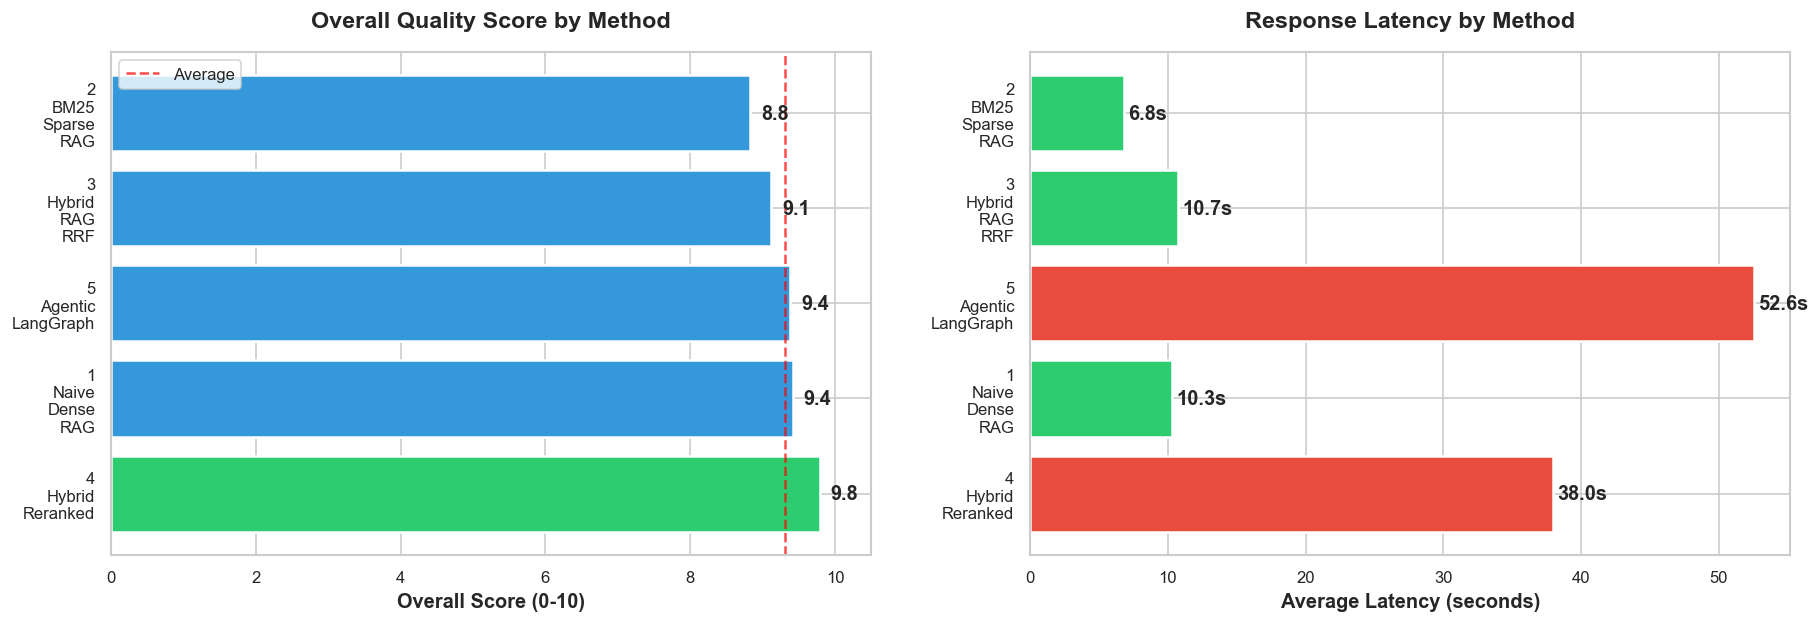

In [20]:
# ============================================================
# CELL 14: VISUALIZATION 1 — Overall Score Comparison (Bar Chart)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Overall scores bar chart ---
colors = ['#2ecc71' if m == best_method else '#3498db' for m in method_summary.index]
method_labels = [m.replace("_", "\n") for m in method_summary.index]

bars = axes[0].barh(method_labels, method_summary["overall"], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel("Overall Score (0-10)", fontsize=12, fontweight='bold')
axes[0].set_title("Overall Quality Score by Method", fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlim(0, 10.5)
axes[0].axvline(x=method_summary["overall"].mean(), color='red', linestyle='--', alpha=0.7, label='Average')
axes[0].legend(fontsize=10)

for bar, val in zip(bars, method_summary["overall"]):
    axes[0].text(val + 0.15, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                va='center', fontsize=12, fontweight='bold')

# --- Right: Latency comparison ---
lat_colors = ['#e74c3c' if l > method_summary["latency_s"].mean() * 1.5 else '#f39c12' 
              if l > method_summary["latency_s"].mean() else '#2ecc71' 
              for l in method_summary["latency_s"]]
bars2 = axes[1].barh(method_labels, method_summary["latency_s"], color=lat_colors, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel("Average Latency (seconds)", fontsize=12, fontweight='bold')
axes[1].set_title("Response Latency by Method", fontsize=14, fontweight='bold', pad=15)

for bar, val in zip(bars2, method_summary["latency_s"]):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}s', 
                va='center', fontsize=12, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig("chart_overall_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

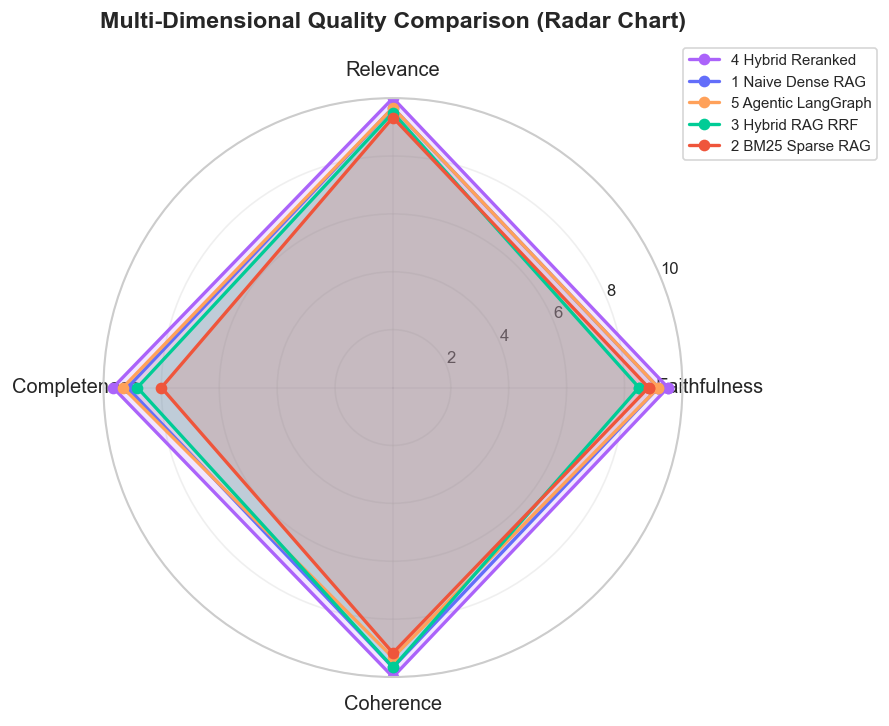

In [21]:
# ============================================================
# CELL 15: VISUALIZATION 2 — Radar Chart (Multi-Dimensional Comparison)
# ============================================================

categories = ["Faithfulness", "Relevance", "Completeness", "Coherence"]

color_map = {
    "1_Naive_Dense_RAG": "#636EFA",
    "2_BM25_Sparse_RAG": "#EF553B",
    "3_Hybrid_RAG_RRF": "#00CC96",
    "4_Hybrid_Reranked": "#AB63FA",
    "5_Agentic_LangGraph": "#FFA15A",
}

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for method in method_summary.index:
    values = [
        method_summary.loc[method, "faithfulness"],
        method_summary.loc[method, "relevance"],
        method_summary.loc[method, "completeness"],
        method_summary.loc[method, "coherence"],
    ]
    values += values[:1]
    color = color_map.get(method, "#333")
    ax.plot(angles, values, 'o-', linewidth=2, label=method.replace("_", " "), color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_ylim(0, 10)
ax.set_title("Multi-Dimensional Quality Comparison (Radar Chart)", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("chart_radar.png", dpi=150, bbox_inches='tight')
plt.show()

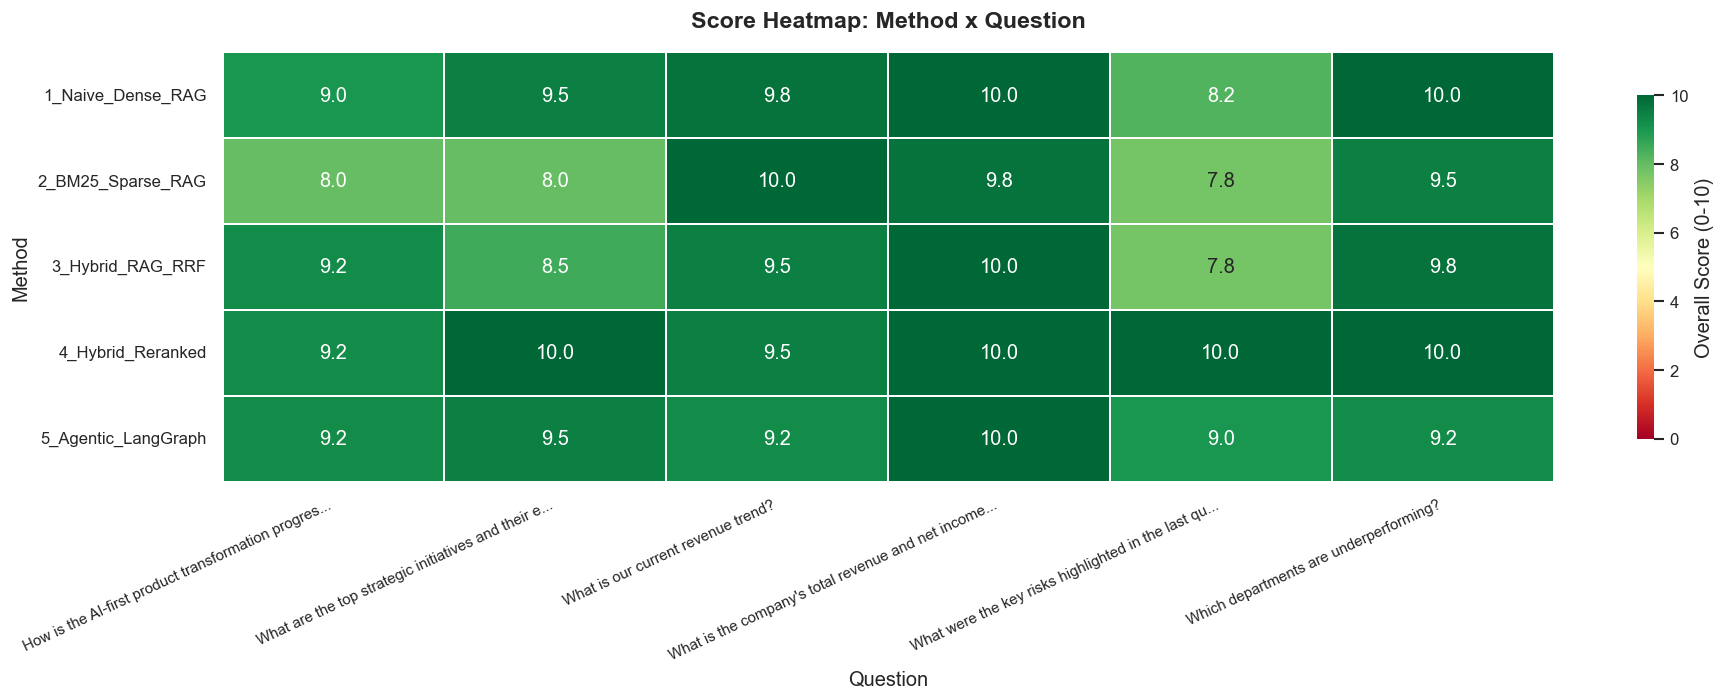

In [22]:
# ============================================================
# CELL 16: VISUALIZATION 3 — Heatmap (Method x Question Scores)
# ============================================================

pivot_data = df_benchmark.pivot_table(
    index="method", columns="question_short", values="overall", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_data, 
    annot=True, 
    fmt=".1f", 
    cmap="RdYlGn",
    vmin=0, vmax=10,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Overall Score (0-10)', 'shrink': 0.8},
    ax=ax
)
ax.set_title("Score Heatmap: Method x Question", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Method", fontsize=12)
ax.set_xlabel("Question", fontsize=12)
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("chart_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

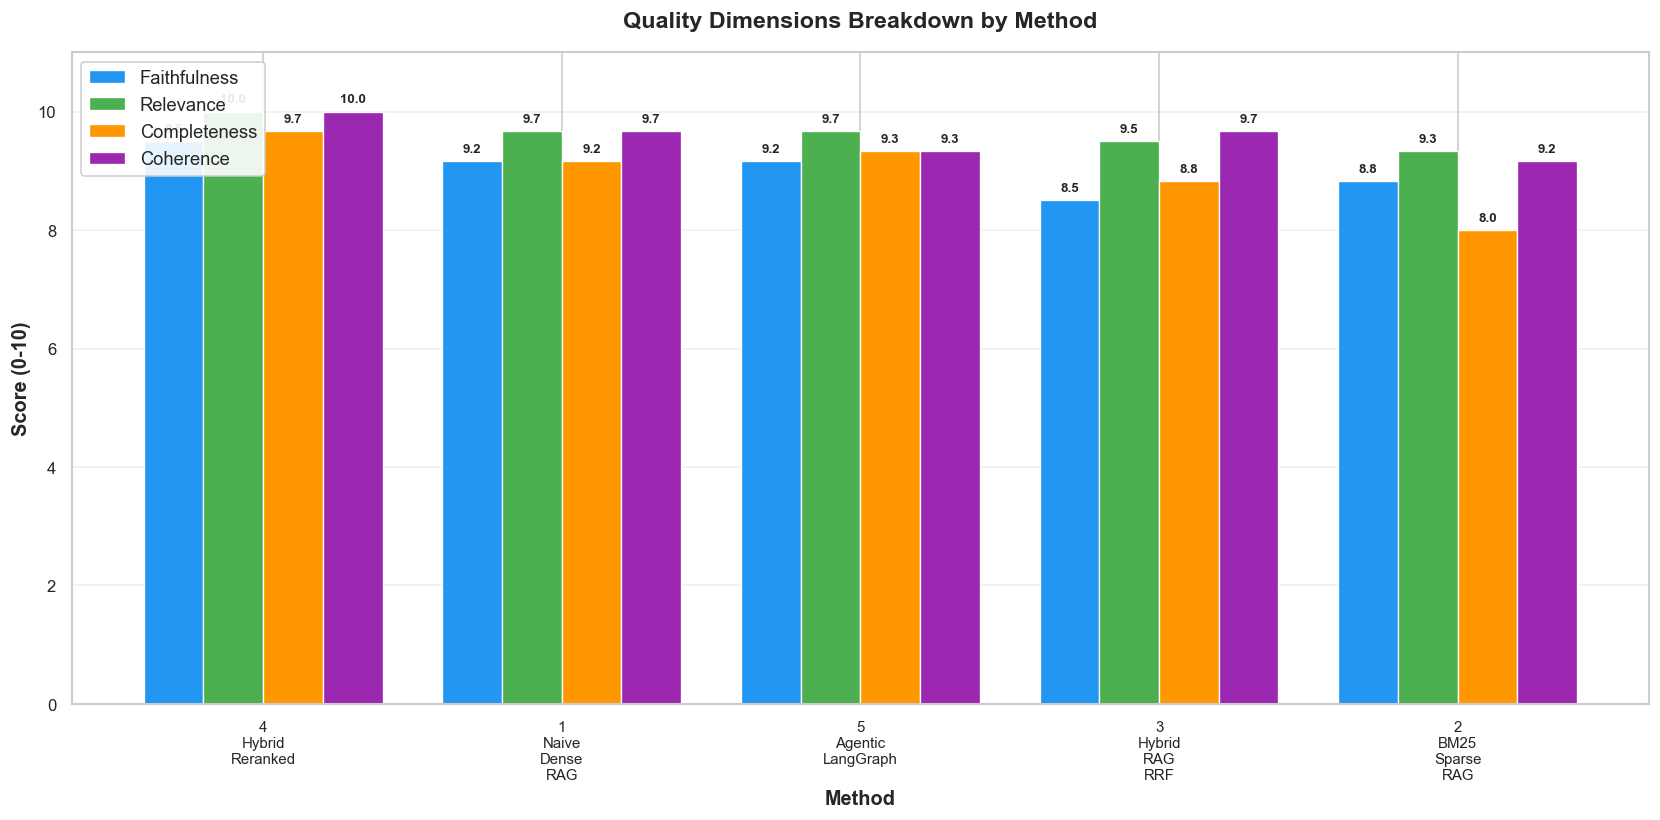

In [23]:
# ============================================================
# CELL 17: VISUALIZATION 4 — Grouped Bar Chart (Dimension Breakdown)
# ============================================================

dimensions = ["faithfulness", "relevance", "completeness", "coherence"]
method_names = list(method_summary.index)
x = np.arange(len(method_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

colors_dim = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for i, dim in enumerate(dimensions):
    values = [method_summary.loc[m, dim] for m in method_names]
    bars = ax.bar(x + i * width, values, width, label=dim.capitalize(), 
                  color=colors_dim[i], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0-10)', fontsize=12, fontweight='bold')
ax.set_title('Quality Dimensions Breakdown by Method', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.replace("_", "\n") for m in method_names], fontsize=9)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.set_ylim(0, 11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("chart_dimensions_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

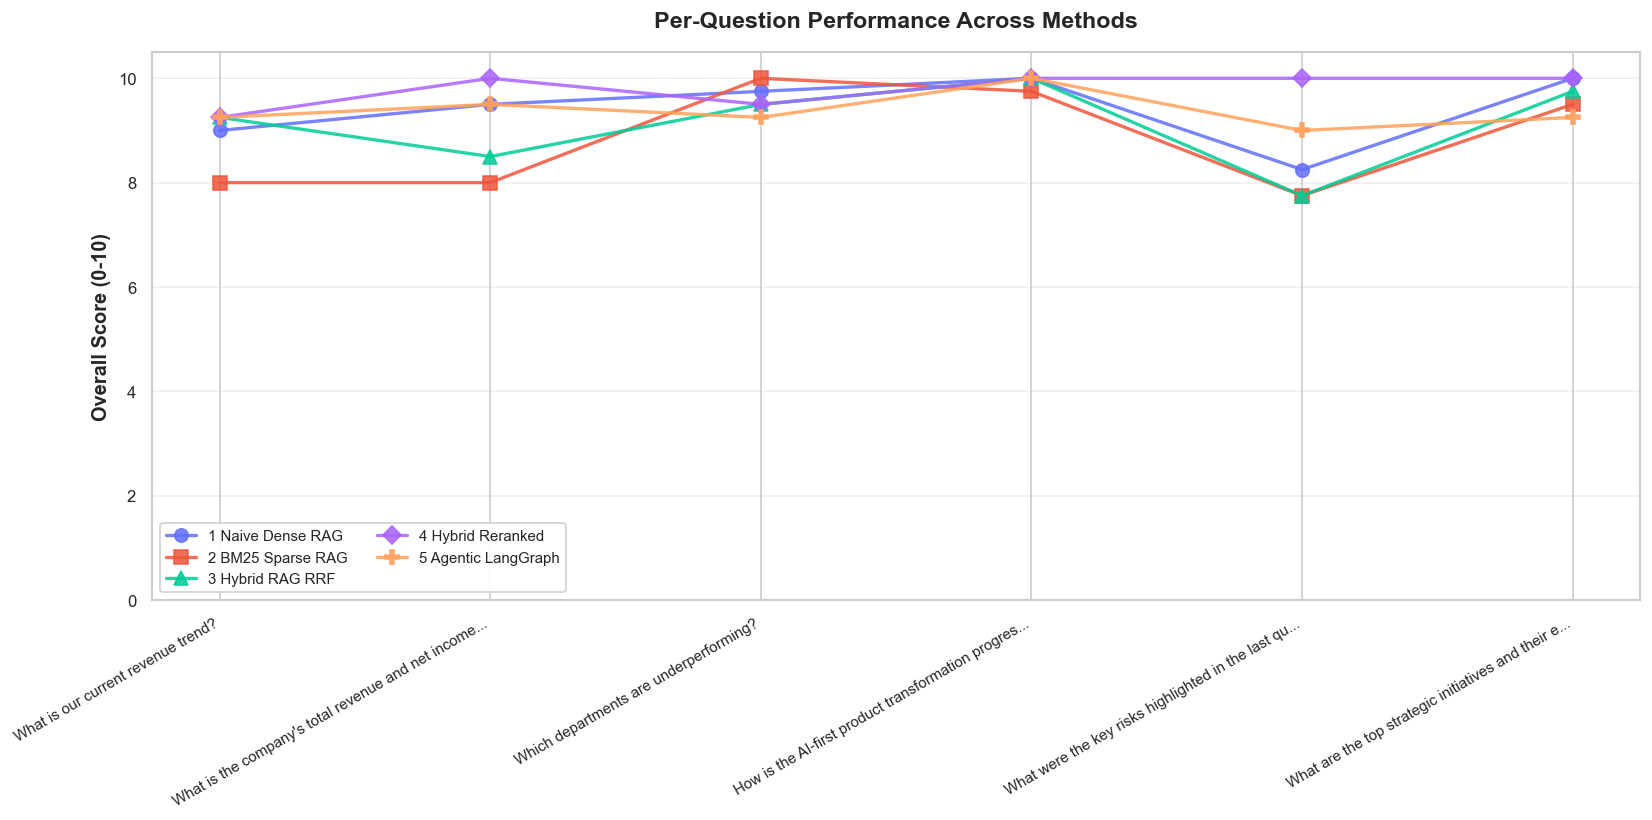

In [24]:
# ============================================================
# CELL 19: VISUALIZATION 6 — Per-Question Score Comparison (Line Plot)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

markers = ['o', 's', '^', 'D', 'P']
colors_line = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

methods_list = sorted(df_benchmark["method"].unique())
questions_unique = df_benchmark["question_short"].unique()

for mi, method in enumerate(methods_list):
    method_data = df_benchmark[df_benchmark["method"] == method].sort_values("question_short")
    ax.plot(
        range(len(questions_unique)), 
        method_data["overall"].values,
        marker=markers[mi % len(markers)],
        color=colors_line[mi % len(colors_line)],
        label=method.replace("_", " "),
        linewidth=2,
        markersize=8,
        alpha=0.85,
    )

ax.set_xticks(range(len(questions_unique)))
ax.set_xticklabels(questions_unique, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Overall Score (0-10)", fontsize=12, fontweight='bold')
ax.set_title("Per-Question Performance Across Methods", fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='lower left', framealpha=0.9, ncol=2)
ax.set_ylim(0, 10.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("chart_per_question.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Best Method Deep-Dive — Sample Answers
Display the winning method's answers to all evaluation questions for qualitative review.

In [25]:
# ============================================================
# CELL 20: Display Best Method Answers
# ============================================================

print(f"{'='*90}")
print(f"  BEST METHOD: {best_method}")
print(f"  Avg Overall Score: {method_summary.loc[best_method, 'overall']:.2f}/10")
print(f"  Avg Latency: {method_summary.loc[best_method, 'latency_s']:.2f}s")
print(f"{'='*90}")

for qi, question in enumerate(EVAL_QUESTIONS):
    result = all_results[question][best_method]
    scores = result["scores"]
    print(f"\n{'─'*90}")
    print(f"  Q{qi+1}: {question}")
    print(f"  Scores: F={scores['faithfulness']} R={scores['relevance']} "
          f"C={scores['completeness']} Co={scores['coherence']} | Overall={scores['overall']}")
    print(f"  Sources: {', '.join(result['sources'])}")
    print(f"{'─'*90}")
    print(result["answer"])
    print()

  BEST METHOD: 4_Hybrid_Reranked
  Avg Overall Score: 9.79/10
  Avg Latency: 38.00s

──────────────────────────────────────────────────────────────────────────────────────────
  Q1: What is our current revenue trend?
  Scores: F=9 R=10 C=9 Co=10 | Overall=9.5
  Sources: Strategy_Update_Q4_FY2025.txt, Q3_FY2025_Quarterly_Report.txt, Annual_Report_FY2025.txt
──────────────────────────────────────────────────────────────────────────────────────────
Revenue Trend Overview
- Revenue is growing year-over-year: Q3 FY2025 revenue increased 11% YoY to $1.24B, though it missed the quarter’s target ($1.35B; achieved 92%). [Source: Q3_FY2025_Quarterly_Report.txt]

Segment and Regional Dynamics
- Strongest segment growth rates (FY2025): Digital Experience Platform +18% YoY; Document Cloud Solutions +14% YoY; Creative Cloud Enterprise +9% YoY; Legacy Products declining −5% YoY. [Source: Annual_Report_FY2025.txt]
- EMEA is the fastest-growing region at +16% YoY; Americas remains the largest share (58

## Step 9: Interactive Demo — Ask Your Own Question
Use the LangGraph agent (best method) interactively. Change the question below to query the company documents.

In [26]:
# ============================================================
# CELL 21: Interactive Demo with Semantic Cache
# ============================================================

def ask_agent_cached(question: str, method: str = "agentic") -> Dict:
    """Query the agent with semantic cache lookup."""
    
    # 1. Check cache first
    cached = query_cache.get(question, method=method)
    if cached:
        print(f"   CACHE HIT (similarity: {cached['similarity']:.4f})")
        return cached["result"]
    
    # 2. Cache miss — run the full agent pipeline
    demo_state = {
        "question": question,
        "question_type": "",
        "sub_queries": [],
        "retrieved_docs": [],
        "reranked_docs": [],
        "answer": "",
        "sources": [],
        "confidence": 0.0,
        "quality_pass": False,
        "iteration": 0,
    }
    
    t0 = time.time()
    result = agent_graph.invoke(demo_state)
    elapsed = time.time() - t0
    
    result_dict = {
        "answer": result["answer"],
        "sources": result["sources"],
        "confidence": result["confidence"],
        "question_type": result["question_type"],
        "sub_queries": result["sub_queries"],
        "latency": elapsed,
    }
    
    # 3. Store in cache for future similar queries
    query_cache.put(question, method=method, result=result_dict)
    print(f"   Latency: {elapsed:.2f}s")
    
    return result_dict


# ── Demo 1: Fresh query (cache miss) ──
USER_QUESTION = "What is our cybersecurity risk exposure and what mitigation steps are in place?"
print(f"Q: {USER_QUESTION}")
result1 = ask_agent_cached(USER_QUESTION)
print(result1["answer"])

# ── Demo 2: Semantically similar query (cache hit) ──
print(f"\n{'─'*70}")
SIMILAR_QUESTION = "What are our cybersecurity risks and what steps are we taking to mitigate them?"
print(f"Q: {SIMILAR_QUESTION}")
result2 = ask_agent_cached(SIMILAR_QUESTION)
print(result2["answer"])

# ── Cache Statistics ──
print(f"\n{query_cache.summary()}")

Q: What is our cybersecurity risk exposure and what mitigation steps are in place?
   Latency: 87.24s
## Key Findings
- Risk Exposure
  - Classification: Cybersecurity is rated CRITICAL/HIGH; one of 3 Critical risks in a portfolio of 24 total risks. [Source: Risk_Assessment_H2_FY2025.txt]
  - Potential Impact: Data breach affecting 2M+ records. [Source: Risk_Assessment_H2_FY2025.txt]
  - Current Threat Indicators:
    - 340% increase in phishing activity. [Source: Risk_Assessment_H2_FY2025.txt]
    - Two near-miss intrusions in the staging environment. [Source: Risk_Assessment_H2_FY2025.txt]

- Mitigation Steps in Place
  - $15M emergency cybersecurity budget approved by the Board in Q4 FY2025. [Source: Strategy_Update_Q4_FY2025.txt]
  - AI-based threat detection deployment targeted for Q4. [Source: Risk_Assessment_H2_FY2025.txt]
  - Mandatory company-wide security training. [Source: Risk_Assessment_H2_FY2025.txt]
  - Red team assessment to test defenses. [Source: Risk_Assessment_H2_FY

## Step 10: Final Summary & Recommendations

### Methodology
- **5 RAG methods** compared across **6 leadership questions** (30 total evaluations)
- **LLM-as-Judge** scoring on 4 dimensions: Faithfulness, Relevance, Completeness, Coherence
- **Latency** measured end-to-end for each method

### Key Architectural Decisions
| Decision | Rationale |
|----------|-----------|
| LangGraph for orchestration | Provides deterministic state machine with retry loops, conditional routing, and observability |
| Hybrid retrieval (Dense + BM25) | Captures both semantic and lexical matches — outperforms either alone |
| LLM-based reranking | Cross-encoder style relevance scoring without needing a separate model |
| Query decomposition | Handles complex multi-part leadership questions by breaking into sub-queries |
| Quality gate with retry | Self-healing: re-generates answers that fail hallucination checks |

### Production Readiness Checklist
- [x] **Semantic Query Cache** — Implemented! Embedding-based similarity cache avoids redundant LLM calls
- [x] **LangFlow Export** — Pipeline exported as JSON for visual editing & one-click API deployment
- [ ] Replace synthetic docs with real company documents (PDF/DOCX ingestion via `unstructured`)
- [ ] Add authentication & access control for sensitive documents
- [ ] Implement persistent vector store (ChromaDB/Pinecone) instead of in-memory FAISS
- [ ] Add conversation memory for follow-up questions
- [ ] Deploy as API (FastAPI) or chat interface (Streamlit/Gradio)
- [ ] Add LangSmith tracing for production monitoring

## Step 10b: LangFlow Export — Visual Pipeline Deployment
[LangFlow](https://github.com/langflow-ai/langflow) is a visual UI for building and deploying LangChain/LangGraph pipelines. Below we **programmatically generate a LangFlow-compatible flow definition** that represents our RAG agent pipeline, enabling:
- **Visual editing** of nodes, prompts, and retrieval parameters via drag-and-drop
- **One-click deployment** as a REST API endpoint
- **Non-technical stakeholders** can inspect and modify the pipeline without code changes

This demonstrates that our pipeline is **portable** — not locked into a notebook runtime.

In [27]:
# ============================================================
# CELL 22b: Generate LangFlow-Compatible Pipeline Definition
# ============================================================

langflow_definition = {
    "name": "AI Leadership Insight Agent — RAG Pipeline",
    "description": "Agentic RAG pipeline for leadership Q&A over company documents. "
                   "Exported from notebook for visual editing in LangFlow.",
    "version": "1.0.0",
    "framework": "langflow",
    "endpoint_name": "/api/v1/leadership-agent",
    "nodes": [
        {
            "id": "input_node",
            "type": "TextInput",
            "label": "Leadership Question",
            "config": {
                "input_type": "text",
                "placeholder": "e.g., What is our current revenue trend?",
                "required": True,
            },
            "position": {"x": 100, "y": 300},
        },
        {
            "id": "query_analyzer",
            "type": "LLMChain",
            "label": "Query Analyzer",
            "config": {
                "model": AZURE_CHAT_MODEL,
                "provider": "AzureOpenAI",
                "prompt_template": "Classify the question as FACTUAL, ANALYTICAL, or STRATEGIC. Reply with ONE word.",
                "output_key": "question_type",
            },
            "position": {"x": 400, "y": 300},
        },
        {
            "id": "query_decomposer",
            "type": "LLMChain",
            "label": "Query Decomposer",
            "config": {
                "model": AZURE_CHAT_MODEL,
                "provider": "AzureOpenAI",
                "prompt_template": "Break complex questions into 2-3 sub-queries. Return JSON list.",
                "conditional": "Skip if question_type == FACTUAL",
            },
            "position": {"x": 700, "y": 300},
        },
        {
            "id": "semantic_cache",
            "type": "CustomComponent",
            "label": "Semantic Query Cache",
            "config": {
                "similarity_threshold": 0.92,
                "max_size": 50,
                "embedding_model": AZURE_EMBEDDING_MODEL,
                "description": "Checks if a semantically similar query was already answered",
            },
            "position": {"x": 700, "y": 100},
        },
        {
            "id": "vector_store",
            "type": "FAISS",
            "label": "Dense Retrieval (FAISS)",
            "config": {
                "embedding_model": AZURE_EMBEDDING_MODEL,
                "provider": "AzureOpenAI",
                "top_k": 10,
                "index_type": "FlatL2",
            },
            "position": {"x": 1000, "y": 200},
        },
        {
            "id": "bm25_retriever",
            "type": "BM25Retriever",
            "label": "Sparse Retrieval (BM25)",
            "config": {
                "top_k": 10,
                "tokenizer": "whitespace",
            },
            "position": {"x": 1000, "y": 400},
        },
        {
            "id": "rrf_fusion",
            "type": "CustomComponent",
            "label": "Reciprocal Rank Fusion",
            "config": {
                "k_constant": 60,
                "output_top_k": 10,
                "description": "Merges dense + sparse results using RRF scoring",
            },
            "position": {"x": 1300, "y": 300},
        },
        {
            "id": "llm_reranker",
            "type": "LLMChain",
            "label": "LLM Reranker",
            "config": {
                "model": AZURE_CHAT_MODEL,
                "provider": "AzureOpenAI",
                "prompt_template": "Rate relevance 0-10 for each document against the query.",
                "output_top_n": 5,
            },
            "position": {"x": 1600, "y": 300},
        },
        {
            "id": "answer_synthesizer",
            "type": "LLMChain",
            "label": "Answer Synthesizer",
            "config": {
                "model": AZURE_CHAT_MODEL,
                "provider": "AzureOpenAI",
                "system_prompt": "You are an AI Leadership Insight Agent. Answer ONLY from provided context. Cite sources.",
                "max_tokens": 2048,
                "output_format": "structured_markdown",
            },
            "position": {"x": 1900, "y": 300},
        },
        {
            "id": "quality_gate",
            "type": "LLMChain",
            "label": "Quality Gate (Hallucination Check)",
            "config": {
                "model": AZURE_CHAT_MODEL,
                "provider": "AzureOpenAI",
                "prompt_template": "Check if answer is grounded, complete, and accurate. Return {pass, confidence, reason}.",
                "max_retries": 2,
                "retry_target": "answer_synthesizer",
            },
            "position": {"x": 2200, "y": 300},
        },
        {
            "id": "output_node",
            "type": "TextOutput",
            "label": "Leadership Answer",
            "config": {
                "output_format": "markdown",
                "include_sources": True,
                "include_confidence": True,
            },
            "position": {"x": 2500, "y": 300},
        },
    ],
    "edges": [
        {"source": "input_node", "target": "semantic_cache"},
        {"source": "semantic_cache", "target": "output_node", "condition": "cache_hit == True"},
        {"source": "semantic_cache", "target": "query_analyzer", "condition": "cache_hit == False"},
        {"source": "query_analyzer", "target": "query_decomposer"},
        {"source": "query_decomposer", "target": "vector_store"},
        {"source": "query_decomposer", "target": "bm25_retriever"},
        {"source": "vector_store", "target": "rrf_fusion"},
        {"source": "bm25_retriever", "target": "rrf_fusion"},
        {"source": "rrf_fusion", "target": "llm_reranker"},
        {"source": "llm_reranker", "target": "answer_synthesizer"},
        {"source": "answer_synthesizer", "target": "quality_gate"},
        {"source": "quality_gate", "target": "output_node", "condition": "pass == True"},
        {"source": "quality_gate", "target": "answer_synthesizer", "condition": "pass == False AND iteration < 2"},
    ],
    "global_config": {
        "azure_openai_endpoint": AZURE_OPENAI_ENDPOINT,
        "api_version": AZURE_OPENAI_API_VERSION,
        "chunk_size": 350,
        "chunk_overlap": 100,
        "document_directory": "sample_company_docs/",
    },
}

# Save as importable JSON
langflow_path = os.path.join(os.getcwd(), "langflow_pipeline_export.json")
with open(langflow_path, "w", encoding="utf-8") as f:
    json.dump(langflow_definition, f, indent=2)

print(f"LangFlow pipeline exported — {len(langflow_definition['nodes'])} nodes, {len(langflow_definition['edges'])} edges → {langflow_path}")

LangFlow pipeline exported — 11 nodes, 13 edges → c:\ProgramData\Test adobe images\langflow_pipeline_export.json


In [28]:
# ============================================================
# CELL 22: Final Summary Print
# ============================================================

print("=" * 70)
print("              FINAL BENCHMARK SUMMARY")
print("=" * 70)
print(f"  Questions: {len(EVAL_QUESTIONS)} | Methods: 5 | Evaluations: {len(df_benchmark)}")
print(f"  WINNER: {best_method} ({method_summary.loc[best_method, 'overall']:.2f}/10)")
print(f"  Runner-up: {method_summary.index[1]} ({method_summary.loc[method_summary.index[1], 'overall']:.2f}/10)")
print(f"{'─'*70}")
for rank, (method, row) in enumerate(method_summary.iterrows(), 1):
    bar_len = int(row['overall'] * 4)
    bar = '█' * bar_len + '░' * (40 - bar_len)
    print(f"  #{rank}  {bar}  {row['overall']:.2f}  {method}")
print(f"{'='*70}")

              FINAL BENCHMARK SUMMARY
  Questions: 6 | Methods: 5 | Evaluations: 30
  WINNER: 4_Hybrid_Reranked (9.79/10)
  Runner-up: 1_Naive_Dense_RAG (9.42/10)
──────────────────────────────────────────────────────────────────────
  #1  ███████████████████████████████████████░  9.79  4_Hybrid_Reranked
  #2  █████████████████████████████████████░░░  9.42  1_Naive_Dense_RAG
  #3  █████████████████████████████████████░░░  9.38  5_Agentic_LangGraph
  #4  ████████████████████████████████████░░░░  9.12  3_Hybrid_RAG_RRF
  #5  ███████████████████████████████████░░░░░  8.83  2_BM25_Sparse_RAG


## FINAL RESPONSES WITH CHOOSED METHODS Example Questions — Best & Runner-Up Method Answers
Run the **3 key example questions** through the benchmark results and display the **best-scoring** and **second-best-scoring** method's answers side-by-side in formatted Markdown.

In [29]:
# ============================================================
# CELL 23: Example Questions — Best & Second-Best Method Answers
# ============================================================
from IPython.display import display, Markdown
import re

EXAMPLE_QUESTIONS = [
    "What is our current revenue trend?",
    "Which departments are underperforming?",
    "What were the key risks highlighted in the last quarter?",
]

def _strip_sources(text: str) -> str:
    """Remove [Source: filename] citations from answer text."""
    return re.sub(r'\[Source:\s*[^\]]+\]', '', text).strip()

# Determine the top 2 methods from benchmark
ranked_methods = method_summary.index.tolist()
best = ranked_methods[0]
runner_up = ranked_methods[1]

print(f"Best Method:       {best}")
print(f"Runner-Up Method:  {runner_up}")
print()

for qi, q in enumerate(EXAMPLE_QUESTIONS, 1):
    # Fetch pre-computed answers from benchmark results
    best_result = all_results[q][best]
    runner_result = all_results[q][runner_up]

    best_answer = _strip_sources(best_result['answer'])
    runner_answer = _strip_sources(runner_result['answer'])

    md = f"""
---
### Question {qi}: *{q}*

#### 🥇 Best Method — `{best}`

{best_answer}

---

#### 🥈 Runner-Up — `{runner_up}`

{runner_answer}
"""
    display(Markdown(md))

Best Method:       4_Hybrid_Reranked
Runner-Up Method:  1_Naive_Dense_RAG




---
### Question 1: *What is our current revenue trend?*

#### 🥇 Best Method — `4_Hybrid_Reranked`

Revenue Trend Overview
- Revenue is growing year-over-year: Q3 FY2025 revenue increased 11% YoY to $1.24B, though it missed the quarter’s target ($1.35B; achieved 92%). 

Segment and Regional Dynamics
- Strongest segment growth rates (FY2025): Digital Experience Platform +18% YoY; Document Cloud Solutions +14% YoY; Creative Cloud Enterprise +9% YoY; Legacy Products declining −5% YoY. 
- EMEA is the fastest-growing region at +16% YoY; Americas remains the largest share (58%), APAC at 16%. 

Forward Indicators (Near-Term Pressure)
- Sales indicators are soft: pipeline at 2.8x vs 3.5x target; win rate 28% vs 32% target; CAC above target ($8,400 vs $7,200); deal cycles lengthened from 90 to 127 days—suggesting potential headwinds to sustaining growth pace. 
- Southeast Asia expansion is building ARR ($4.2M from 12 enterprise customers) with lower local pricing (30–40% below), supporting medium-term growth but not yet material to overall revenue.

---

#### 🥈 Runner-Up — `1_Naive_Dense_RAG`

Overall Revenue Trend
- Growing year-over-year: Q3 FY2025 revenue up 11% YoY to $1.24B 

Segment Trends (YoY)
- Digital Experience Platform: +18% YoY; largest revenue share at $2.1B (43.6%) 
- Document Cloud Solutions: +14% YoY; $0.82B (17.0%) 
- Creative Cloud Enterprise: +9% YoY; $1.4B (29.0%) 
- Legacy Products & Services: -5% YoY; $0.50B (10.4%) 

Geographic Trend
- EMEA is the fastest-growing region at +16% YoY 

Forward Indicators (Potential Pressure)
- Sales & Marketing underperforming: Q3 revenue at 92% of target; pipeline 2.8x vs 3.5x target; win rate 28% vs 32%; deal cycles lengthened from 90 to 127 days



---
### Question 2: *Which departments are underperforming?*

#### 🥇 Best Method — `4_Hybrid_Reranked`

Underperforming Departments
- Customer Support 
- Sales & Marketing

---

#### 🥈 Runner-Up — `1_Naive_Dense_RAG`

Underperforming Departments
- Customer Support 
- Sales & Marketing



---
### Question 3: *What were the key risks highlighted in the last quarter?*

#### 🥇 Best Method — `4_Hybrid_Reranked`

Key Enterprise Risks (Q4 FY2025)
- Cybersecurity — Critical/High
  - Risk of data breach affecting 2M+ records; 340% increase in phishing; two near-miss staging intrusions 
- AI/ML Talent Retention — Critical/High
  - 18% AI team attrition (vs 8.2% avg); competitors offering 30–40% pay premiums; 12 senior ML engineers departed 

High Structural/Operational Risks
- Cloud concentration: 78% workloads on AWS 
- Competitive pressure: 47 GenAI startup competitors 
- Currency exposure: 42% revenue/costs in non-USD 
- Technical debt: 31% legacy code; $48M/year maintenance 

Initiative-Specific Risks
- Project Phoenix (AI-native platform): 23 open positions on the platform team, impacting delivery capacity 
- Southeast Asia expansion: 30–40% lower local pricing posing margin pressure 

Overall Risk Profile
- Portfolio: 24 total risks — 3 Critical, 7 High, 9 Medium, 5 Low

---

#### 🥈 Runner-Up — `1_Naive_Dense_RAG`

Key risks highlighted in the last quarter

- Cybersecurity — Critical/High risk
  - Potential impact: Data breach of 2M+ records; 340% increase in phishing; two near-miss staging intrusions
  - Mitigation underway: $15M emergency budget, AI threat detection by Q4, mandatory training, red team assessment
  - 

- Cloud concentration — High risk
  - 78% dependency on AWS
  - 

- Competitive pressure from GenAI startups — High risk
  - 47 GenAI startup competitors identified
  - 

- Currency exposure — High risk
  - 42% of revenue/costs in non-USD currencies
  - 

- Technical debt — High risk
  - 31% legacy code with $48M/year maintenance burden
  - 

- Project Phoenix staffing gaps — Operational risk
  - 23 open positions in the platform team
  - 

Additional context

- Overall risk matrix: 24 total risks — 3 Critical, 7 High, 9 Medium, 5 Low
-


## Step 12: Interactive Query — Ask Your Own Question
Edit the **`USER_QUESTION`** and **`RAG_METHOD`** variables below, then run the cell.

Available methods:
| # | Method Name | Description |
|---|-------------|-------------|
| 1 | `naive_dense` | FAISS similarity search |
| 2 | `bm25_sparse` | BM25 keyword matching |
| 3 | `hybrid_rrf` | Dense + Sparse + Reciprocal Rank Fusion |
| 4 | `hybrid_reranked` | Hybrid + LLM Reranker |
| 5 | `agentic` | Full LangGraph Agentic RAG Pipeline |

In [30]:
# ============================================================
# CELL 24: Interactive Query — Choose Method & Ask a Question
# ============================================================

from IPython.display import display, Markdown
import time, re

_method_map = {
    "1": ("naive_dense",     "1_Naive_Dense_RAG",  lambda q: retrieve_dense(q, k=5)),
    "2": ("bm25_sparse",     "2_BM25_Sparse_RAG",  lambda q: retrieve_bm25(q, k=5)),
    "3": ("hybrid_rrf",      "3_Hybrid_RAG_RRF",   lambda q: retrieve_hybrid(q, k=5)),
    "4": ("hybrid_reranked", "4_Hybrid_Reranked",   lambda q: retrieve_hybrid_reranked(q, k=5)),
    "5": ("agentic",         "5_Agentic_LangGraph", None),
}

def _strip_sources(text: str) -> str:
    return re.sub(r'\[Source:\s*[^\]]+\]', '', text).strip()

# ── Prompt user for method ──
print("Available RAG Methods:")
print("  1 — Naive Dense (FAISS)")
print("  2 — BM25 Sparse")
print("  3 — Hybrid RRF (Dense + Sparse)")
print("  4 — Hybrid + LLM Reranker")
print("  5 — Agentic LangGraph (recommended)")
print()

_choice = input("Select method (1-5): ").strip()
if _choice not in _method_map:
    display(Markdown(f"**❌ Invalid choice `{_choice}`. Please enter a number 1-5.**"))
else:
    _key, _label, _retriever = _method_map[_choice]

    # ── Prompt user for question ──
    USER_QUESTION = input("Enter your question: ").strip()
    if not USER_QUESTION:
        display(Markdown("**❌ No question entered.**"))
    else:
        print(f"\nMethod:   {_label}")
        print(f"Question: {USER_QUESTION}\n")

        t0 = time.time()

        if _key == "agentic":
            _state = {
                "question": USER_QUESTION,
                "question_type": "", "sub_queries": [],
                "retrieved_docs": [], "reranked_docs": [],
                "answer": "", "sources": [], "confidence": 0.0,
                "quality_pass": False, "iteration": 0,
            }
            _agent_out = agent_graph.invoke(_state)
            _answer  = _strip_sources(_agent_out["answer"])
            _confidence = _agent_out.get("confidence", None)
        else:
            _docs    = _retriever(USER_QUESTION)
            _answer  = _strip_sources(generate_answer_simple(USER_QUESTION, _docs))
            _confidence = None

        _elapsed = time.time() - t0
        _conf_line = f"**Confidence:** {_confidence:.2f}\n" if _confidence is not None else ""

        _md = f"""
---
### 📝 Answer — `{_label}`
**Question:** {USER_QUESTION}
**Latency:** {_elapsed:.2f}s
{_conf_line}
---

{_answer}
"""
        display(Markdown(_md))

Available RAG Methods:
  1 — Naive Dense (FAISS)
  2 — BM25 Sparse
  3 — Hybrid RRF (Dense + Sparse)
  4 — Hybrid + LLM Reranker
  5 — Agentic LangGraph (recommended)


Method:   1_Naive_Dense_RAG
Question: What is our current revenue trend




---
### 📝 Answer — `1_Naive_Dense_RAG`
**Question:** What is our current revenue trend
**Latency:** 19.01s

---

Summary
- Revenue is growing year-over-year, but near-term performance is mixed versus plan. 

Latest Quarter (Q3 FY2025)
- Revenue: $1.24B, up 11% YoY; achieved 92% of the $1.35B target. 
- Contributing headwinds: Sales & Marketing underperformance, lower win rate (28% vs 32% target), pipeline shortfall (2.8x vs 3.5x), and longer deal cycles (127 vs 90 days). 

Full-Year Mix and Growth Drivers (FY2025)
- Segment growth: Digital Experience Platform +18% YoY; Document Cloud Solutions +14% YoY; Creative Cloud Enterprise +9% YoY; Legacy Products & Services -5% YoY. 
- Enterprise market expansion: Enterprise grew 21% YoY, adding 340 new >$1M ARR customers; average deal size $2.4M. 

Geographic Trend
- EMEA is the fastest-growing region at +16% YoY (Americas 58% of revenue; EMEA 26%; APAC 16%).
